REAL-TIME CREDIT RISK REASSESSMENT -- single-file demo

[1/4] Training initial model on synthetic historical data...
      Model 'v1' trained and saved to /content/models

[2/4] Ingesting edge-case event batches...
      edge_case_1_identity_conflict: 3 processed, 0 duplicate/idempotent
      edge_case_2_replay_duplicate: 2 processed, 1 duplicate/idempotent
      edge_case_3_late_event: 3 processed, 0 duplicate/idempotent


/tmp/ipykernel_1311/306414412.py:384: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([self.history, df], ignore_index=True, sort=False)
/tmp/ipykernel_1311/306414412.py:462: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.history = pd.concat([self.history, pd.DataFrame(new_rows_buffer)], ignore_index=True, sort=False)


      edge_case_4_temporal_drift: 40 processed, 0 duplicate/idempotent
      edge_case_5_conflicting_default_labels: 4 processed, 0 duplicate/idempotent
      edge_case_6_missing_id_fuzzy_match: 2 processed, 0 duplicate/idempotent
      edge_case_7_overlapping_windows: 4 processed, 0 duplicate/idempotent

[3/4] Sanity checks...
      Idempotency check passed (replay produced no new state changes)
      Drift detection check passed (temporal shift correctly flagged)

[4/4] Generating demo plot (risk score evolution for ACC9004)...
      Saved to /content/demo/risk_score_evolution.png

DONE. 58 audit trail files written to: /content/audit_logs
Risk state persisted to: /content/models/risk_state.json


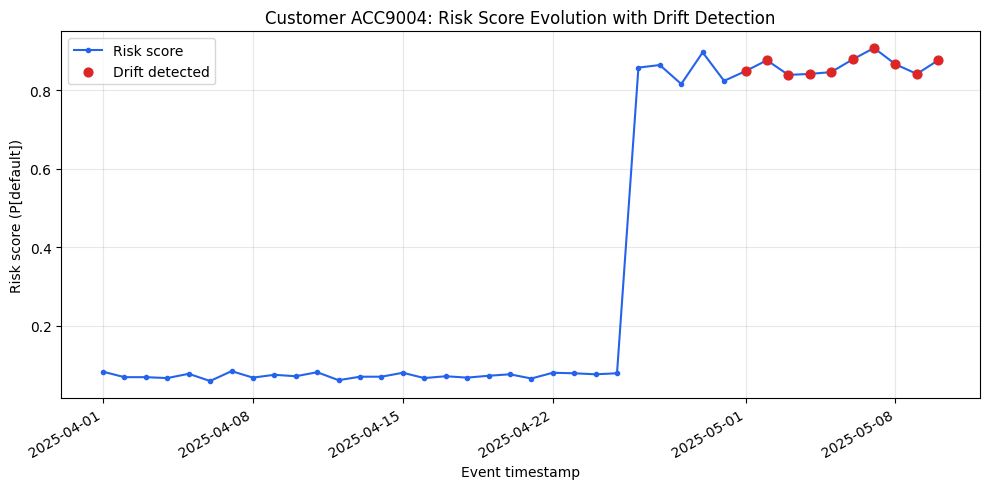

In [ ]:
from __future__ import annotations

# import numpy as np
import difflib
import json
import os
import pickle
from collections import Counter
from dataclasses import dataclass, field
from typing import Dict, List, Optional

# pip install numpy

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# ---------------------------------------------------------------------------
# Paths (all local, no external DB/services)
# ---------------------------------------------------------------------------
BASE_DIR = os.getcwd()
MODELS_DIR = os.path.join(BASE_DIR, "models")
AUDIT_DIR = os.path.join(BASE_DIR, "audit_logs")
DEMO_DIR = os.path.join(BASE_DIR, "demo")
STATE_PATH = os.path.join(MODELS_DIR, "risk_state.json")
EVENT_LOG_PATH = os.path.join(AUDIT_DIR, "event_log.json")
HISTORY_PATH = os.path.join(AUDIT_DIR, "full_history.csv")

REQUIRED_COLUMNS = [
    "event_id", "timestamp", "customer_id", "account_id",
    "payment_delay", "transaction_count", "credit_inquiry", "source", "is_default",
]
FEATURES = ["payment_delay", "transaction_count", "credit_inquiry"]
CURRENT_MODEL_VERSION = "v1"


# ===========================================================================
# 1. IDENTITY RESOLUTION ENGINE
# ===========================================================================
CUSTOMER_ID_SIMILARITY_THRESHOLD = 0.85
TRANSACTION_COUNT_MAX_DELTA = 2


class UnionFind:
    def __init__(self, ids: List[int]):
        self.parent = {i: i for i in ids}

    def find(self, x: int) -> int:
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, x: int, y: int) -> None:
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return
        if rx < ry:
            self.parent[ry] = rx
        else:
            self.parent[rx] = ry


def _is_missing(value) -> bool:
    if value is None:
        return True
    if isinstance(value, str) and value.strip() == "":
        return True
    try:
        if pd.isna(value):
            return True
    except (TypeError, ValueError):
        pass
    return False


def _customer_id_similar(a, b) -> bool:
    if _is_missing(a) or _is_missing(b):
        return False
    if a == b:
        return True
    ratio = difflib.SequenceMatcher(None, str(a), str(b)).ratio()
    return ratio >= CUSTOMER_ID_SIMILARITY_THRESHOLD


def _transaction_counts_close(a, b) -> bool:
    if _is_missing(a) or _is_missing(b):
        return False
    try:
        return abs(float(a) - float(b)) <= TRANSACTION_COUNT_MAX_DELTA
    except (TypeError, ValueError):
        return False


def resolve_identities(events: pd.DataFrame) -> pd.DataFrame:
    """
    Deterministic identity resolution:
      1. account_id is authoritative -- shared account_id => same customer.
      2. Missing account_id falls back to fuzzy customer_id matching +
         transaction_count proximity, but ONLY against other events that
         also lack an account_id (an authoritative account_id elsewhere
         must never be overridden by a fuzzy match).
      3. Union-Find clusters events; canonical id = shared account_id, or
         else the lexicographically smallest customer_id in the cluster.
      Processing is always on events sorted by event_id, so the result is
      independent of input order (replay-safe).
    """
    df = events.sort_values("event_id", kind="stable").reset_index(drop=True)
    n = len(df)
    uf = UnionFind(list(range(n)))

    account_ids = df["account_id"].tolist() if "account_id" in df.columns else [None] * n
    customer_ids = df["customer_id"].tolist() if "customer_id" in df.columns else [None] * n
    txn_counts = df["transaction_count"].tolist() if "transaction_count" in df.columns else [None] * n
    reasons = ["no_match_found"] * n

    # Pass 1: merge on account_id.
    seen: Dict[str, int] = {}
    for i in range(n):
        acc = account_ids[i]
        if _is_missing(acc):
            continue
        key = str(acc)
        if key in seen:
            uf.union(seen[key], i)
            reasons[i] = "matched_account_id"
        else:
            seen[key] = i

    # Pass 2: fuzzy match, only among events that also lack an account_id.
    for i in range(n):
        if not _is_missing(account_ids[i]):
            continue
        for j in range(i):
            if uf.find(i) == uf.find(j):
                continue
            if not _is_missing(account_ids[j]):
                continue
            if _customer_id_similar(customer_ids[i], customer_ids[j]) and _transaction_counts_close(
                txn_counts[i], txn_counts[j]
            ):
                uf.union(i, j)
                reasons[i] = "fuzzy_matched_customer_id_and_transaction_history"
                break

    clusters: Dict[int, List[int]] = {}
    for i in range(n):
        clusters.setdefault(uf.find(i), []).append(i)

    merged_ids = [None] * n
    for root, members in clusters.items():
        member_accounts = [account_ids[m] for m in members if not _is_missing(account_ids[m])]
        member_customers = sorted({str(customer_ids[m]) for m in members if not _is_missing(customer_ids[m])})
        if member_accounts:
            canonical = str(sorted({str(a) for a in member_accounts})[0])
        elif member_customers:
            canonical = member_customers[0]
        else:
            canonical = f"UNKNOWN_CUSTOMER_{root}"
        for m in members:
            merged_ids[m] = canonical

    df["merged_customer_id"] = merged_ids
    df["resolution_reason"] = reasons
    return df


# ===========================================================================
# 2. TEMPORAL DRIFT DETECTION (manual KS-test, no SciPy)
# ===========================================================================
DRIFT_KS_THRESHOLD = 0.3
DRIFT_MEAN_PCT_THRESHOLD = 0.15
ROLLING_WINDOW_DAYS = 30
DRIFT_FEATURES = ["payment_delay", "transaction_count", "credit_inquiry"]


@dataclass
class DriftResult:
    feature: str
    ks_statistic: float
    baseline_mean: float
    current_mean: float
    mean_pct_change: float
    drifted: bool


def _ks_statistic(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) == 0 or len(b) == 0:
        return 0.0
    all_vals = np.sort(np.concatenate([a, b]))
    cdf_a = np.searchsorted(np.sort(a), all_vals, side="right") / len(a)
    cdf_b = np.searchsorted(np.sort(b), all_vals, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))


def detect_drift(customer_history: pd.DataFrame, as_of: pd.Timestamp) -> List[DriftResult]:
    results: List[DriftResult] = []
    window_start = as_of - pd.Timedelta(days=ROLLING_WINDOW_DAYS)
    current_window = customer_history[
        (customer_history["timestamp"] > window_start) & (customer_history["timestamp"] <= as_of)
    ]
    baseline_window = customer_history[customer_history["timestamp"] <= window_start]

    if baseline_window.empty:
        return [DriftResult(f, 0.0, 0.0, 0.0, 0.0, False) for f in DRIFT_FEATURES]

    for feature in DRIFT_FEATURES:
        if feature not in customer_history.columns:
            continue
        base_vals = pd.to_numeric(baseline_window[feature], errors="coerce").dropna().to_numpy()
        curr_vals = pd.to_numeric(current_window[feature], errors="coerce").dropna().to_numpy()
        if len(base_vals) == 0 or len(curr_vals) == 0:
            results.append(DriftResult(feature, 0.0, 0.0, 0.0, 0.0, False))
            continue
        ks_stat = _ks_statistic(base_vals, curr_vals)
        base_mean, curr_mean = float(np.mean(base_vals)), float(np.mean(curr_vals))
        mean_pct_change = abs(curr_mean - base_mean) / abs(base_mean) if base_mean != 0 else (1.0 if curr_mean != 0 else 0.0)
        drifted = ks_stat > DRIFT_KS_THRESHOLD or mean_pct_change > DRIFT_MEAN_PCT_THRESHOLD
        results.append(DriftResult(feature, round(ks_stat, 4), round(base_mean, 4), round(curr_mean, 4), round(mean_pct_change, 4), drifted))
    return results


def any_drift(results: List[DriftResult]) -> bool:
    return any(r.drifted for r in results)


def drift_results_to_dict(results: List[DriftResult]) -> Dict:
    return {r.feature: r.__dict__ for r in results}


# ===========================================================================
# 3. STATEFUL RISK REASSESSMENT (versioned Logistic Regression)
# ===========================================================================
def train_model(historical_df: pd.DataFrame, version: str) -> LogisticRegression:
    df = historical_df.dropna(subset=FEATURES + ["is_default"]).copy()
    X = df[FEATURES].astype(float).to_numpy()
    y = df["is_default"].astype(int).to_numpy()
    model = LogisticRegression(max_iter=1000, random_state=42)
    if len(np.unique(y)) < 2:
        X = np.vstack([X, X[-1:] + 1e-3])
        y = np.append(y, 1 - y[-1])
    model.fit(X, y)
    os.makedirs(MODELS_DIR, exist_ok=True)
    with open(os.path.join(MODELS_DIR, f"model_{version}.pkl"), "wb") as f:
        pickle.dump(model, f)
    return model


def score_features(model: LogisticRegression, feature_row: Dict[str, float]) -> float:
    x = np.array([[float(feature_row.get(f, 0.0) or 0.0) for f in FEATURES]])
    proba = model.predict_proba(x)[0]
    classes = list(model.classes_)
    return float(proba[classes.index(1)]) if 1 in classes else float(proba[0])


@dataclass
class RiskState:
    state: Dict[str, Dict] = field(default_factory=dict)

    @classmethod
    def load(cls) -> "RiskState":
        if os.path.exists(STATE_PATH):
            with open(STATE_PATH, "r") as f:
                return cls(state=json.load(f))
        return cls(state={})

    def save(self) -> None:
        os.makedirs(MODELS_DIR, exist_ok=True)
        with open(STATE_PATH, "w") as f:
            json.dump(self.state, f, indent=2, default=str)

    def get(self, customer_id: str) -> Optional[Dict]:
        return self.state.get(customer_id)

    def update(self, customer_id: str, score: float, model_version: str, last_event_id: str, last_timestamp: str) -> None:
        self.state[customer_id] = {
            "score": round(float(score), 6),
            "model_version": model_version,
            "last_event_id": last_event_id,
            "last_timestamp": str(last_timestamp),
        }


# ===========================================================================
# 4. EVENT REPLAY & IDEMPOTENCY
# ===========================================================================
class EventLog:
    def __init__(self):
        self.processed: Dict[str, Dict] = {}
        if os.path.exists(EVENT_LOG_PATH):
            with open(EVENT_LOG_PATH, "r") as f:
                self.processed = json.load(f)

    def save(self) -> None:
        os.makedirs(AUDIT_DIR, exist_ok=True)
        with open(EVENT_LOG_PATH, "w") as f:
            json.dump(self.processed, f, indent=2, default=str)

    def is_processed(self, event_id: str) -> bool:
        return str(event_id) in self.processed

    def mark_processed(self, event_id: str, merged_customer_id: str, audit_file: str) -> None:
        self.processed[str(event_id)] = {"merged_customer_id": merged_customer_id, "audit_file": audit_file}

    def get(self, event_id: str) -> Optional[Dict]:
        return self.processed.get(str(event_id))


# ===========================================================================
# 5. AUDIT TRAIL GENERATION
# ===========================================================================
def write_audit(event_ids, merged_customer_id, drift_detected, drift_details, model_version,
                 score, reasoning, late_event=False, duplicate=False, is_default_conflict=None, timestamp="") -> str:
    os.makedirs(AUDIT_DIR, exist_ok=True)
    safe_customer = str(merged_customer_id).replace("/", "_")
    safe_ts = str(timestamp).replace(":", "-").replace(" ", "_")
    filename = f"{safe_customer}_{safe_ts}_{'-'.join(map(str, event_ids))}.json"
    path = os.path.join(AUDIT_DIR, filename)
    record = {
        "event_ids": event_ids, "merged_customer_id": merged_customer_id, "timestamp": timestamp,
        "duplicate_replay": duplicate, "late_event": late_event, "drift_detected": drift_detected,
        "drift_details": drift_details, "model_version": model_version, "score": score,
        "is_default_conflict": is_default_conflict, "reasoning": reasoning,
    }
    with open(path, "w") as f:
        json.dump(record, f, indent=2, default=str)
    return path


def _resolve_is_default_conflict(cluster_events: pd.DataFrame) -> Dict:
    if "is_default" not in cluster_events.columns:
        return {}
    labels = cluster_events["is_default"].dropna()
    if labels.empty or len(labels.unique()) <= 1:
        return {}
    counts = Counter(labels.tolist())
    top_count = max(counts.values())
    tied = [v for v, c in counts.items() if c == top_count]
    if len(tied) == 1:
        return {"conflict": True, "observed_values": {str(k): v for k, v in counts.items()},
                "resolved_value": tied[0], "resolution_method": "majority_vote"}
    tied_rows = cluster_events[cluster_events["is_default"].isin(tied)]
    resolved = tied_rows.sort_values("timestamp").iloc[-1]["is_default"]
    return {"conflict": True, "observed_values": {str(k): v for k, v in counts.items()},
            "resolved_value": resolved, "resolution_method": "majority_vote_tie_broken_by_most_recent_timestamp"}


class MalformedEventError(ValueError):
    pass


def validate_events(df: pd.DataFrame) -> None:
    missing_cols = [c for c in ["event_id", "timestamp"] if c not in df.columns]
    if missing_cols:
        raise MalformedEventError(f"Missing required columns: {missing_cols}")
    if df["event_id"].isna().any():
        raise MalformedEventError("event_id is required for every event")
    if df["timestamp"].isna().any():
        raise MalformedEventError("timestamp is required for every event")


# ===========================================================================
# 6. EVENT PROCESSOR (orchestrates everything, deterministic + idempotent)
# ===========================================================================
class EventProcessor:
    def __init__(self, model_version: str = CURRENT_MODEL_VERSION):
        self.model_version = model_version
        model_path = os.path.join(MODELS_DIR, f"model_{model_version}.pkl")
        self.model = pickle.load(open(model_path, "rb")) if os.path.exists(model_path) else None
        self.risk_state = RiskState.load()
        self.event_log = EventLog()
        self.history = pd.read_csv(HISTORY_PATH, parse_dates=["timestamp"]) if os.path.exists(HISTORY_PATH) else \
            pd.DataFrame(columns=REQUIRED_COLUMNS + ["merged_customer_id"])

    def train_initial_model(self, historical_df: pd.DataFrame) -> None:
        self.model = train_model(historical_df, self.model_version)

    def process_events(self, new_events: pd.DataFrame) -> List[Dict]:
        validate_events(new_events)
        df = new_events.copy()
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df = df.sort_values(["timestamp", "event_id"], kind="stable").reset_index(drop=True)

        combined = pd.concat([self.history, df], ignore_index=True, sort=False)
        combined = combined.drop_duplicates(subset=["event_id"], keep="last")
        combined_resolved = resolve_identities(combined)
        event_id_to_row = {str(r["event_id"]): r for r in combined_resolved.to_dict("records")}

        cluster_buffers: Dict[str, List[Dict]] = {}
        if not self.history.empty:
            for cid, group in self.history.groupby("merged_customer_id"):
                cluster_buffers[cid] = group.to_dict("records")

        results = []
        new_rows_buffer: List[Dict] = []

        for _, event in df.iterrows():
            event_id = str(event["event_id"])
            row = event_id_to_row.get(event_id)
            if row is None:
                continue
            merged_customer_id = row["merged_customer_id"]
            resolution_reason = row["resolution_reason"]

            if self.event_log.is_processed(event_id):
                audit_file = write_audit(
                    event_ids=[event_id], merged_customer_id=merged_customer_id, drift_detected=False,
                    drift_details={}, model_version=self.model_version, score=self.risk_state.get(merged_customer_id),
                    reasoning=["Event already processed; replay is idempotent, no state change."],
                    duplicate=True, timestamp=str(event["timestamp"]),
                )
                results.append({"event_id": event_id, "status": "duplicate", "merged_customer_id": merged_customer_id,
                                 "score": self.risk_state.get(merged_customer_id), "audit_file": audit_file})
                continue

            new_row = event.to_dict()
            new_row["merged_customer_id"] = merged_customer_id
            cluster_buffers.setdefault(merged_customer_id, []).append(new_row)
            new_rows_buffer.append(new_row)

            cluster_history = pd.DataFrame(cluster_buffers[merged_customer_id])
            cluster_history["timestamp"] = pd.to_datetime(cluster_history["timestamp"])

            prior_events = cluster_history[cluster_history["event_id"] != event["event_id"]]
            late_event = not prior_events.empty and event["timestamp"] < prior_events["timestamp"].max()

            cluster_sorted = cluster_history.sort_values("timestamp")
            drift_results = detect_drift(cluster_sorted, as_of=event["timestamp"])
            drift_flag = any_drift(drift_results)
            conflict_info = _resolve_is_default_conflict(cluster_history)

            feature_row = {
                "payment_delay": event.get("payment_delay"),
                "transaction_count": event.get("transaction_count"),
                "credit_inquiry": event.get("credit_inquiry"),
            }
            if self.model is None:
                raise RuntimeError("Model has not been trained. Call train_initial_model() first.")
            score = score_features(self.model, feature_row)
            self.risk_state.update(merged_customer_id, score, self.model_version, event_id, str(event["timestamp"]))

            reasoning = [f"Identity resolution: {resolution_reason}.",
                         f"New event ingested -> risk score recomputed with model {self.model_version}."]
            if drift_flag:
                reasoning.append("Temporal drift detected in one or more features; re-evaluation triggered.")
            if late_event:
                reasoning.append("Event timestamp is earlier than previously seen events for this customer (late event); state updated retroactively.")
            if conflict_info:
                reasoning.append(f"Conflicting is_default labels resolved via {conflict_info['resolution_method']}.")

            audit_file = write_audit(
                event_ids=[event_id], merged_customer_id=merged_customer_id, drift_detected=drift_flag,
                drift_details=drift_results_to_dict(drift_results), model_version=self.model_version, score=score,
                reasoning=reasoning, late_event=late_event, duplicate=False,
                is_default_conflict=conflict_info or None, timestamp=str(event["timestamp"]),
            )
            self.event_log.mark_processed(event_id, merged_customer_id, audit_file)
            results.append({"event_id": event_id, "status": "processed", "merged_customer_id": merged_customer_id,
                             "score": score, "audit_file": audit_file})

        if new_rows_buffer:
            self.history = pd.concat([self.history, pd.DataFrame(new_rows_buffer)], ignore_index=True, sort=False)

        self.event_log.save()
        self.risk_state.save()
        os.makedirs(os.path.dirname(HISTORY_PATH), exist_ok=True)
        self.history.to_csv(HISTORY_PATH, index=False)
        return results


# ===========================================================================
# 7. INLINE SAMPLE DATA GENERATION (so this file is fully self-contained)
# ===========================================================================
def generate_historical_data(seed: int = 42, n: int = 300) -> pd.DataFrame:
    rng = np.random.RandomState(seed)
    hist = pd.DataFrame({
        "event_id": [f"H{i:04d}" for i in range(n)],
        "timestamp": pd.date_range("2025-01-01", periods=n, freq="6h"),
        "customer_id": [f"CUST{i % 150:04d}" for i in range(n)],
        "account_id": [f"ACC{i % 150:04d}" for i in range(n)],
        "payment_delay": rng.exponential(3, n).round(1),
        "transaction_count": rng.poisson(20, n),
        "credit_inquiry": rng.poisson(1, n),
        "source": rng.choice(["payment", "transaction", "credit_inquiry"], n),
    })
    risk_score = 0.15 * hist.payment_delay + 0.6 * hist.credit_inquiry - 0.05 * hist.transaction_count
    prob = 1 / (1 + np.exp(-(risk_score - 2)))
    hist["is_default"] = (rng.rand(n) < prob).astype(int)
    return hist


def generate_edge_case_datasets() -> Dict[str, pd.DataFrame]:
    cases = {}

    cases["1_identity_conflict"] = pd.DataFrame({
        "event_id": ["E1001", "E1002", "E1003"],
        "timestamp": ["2025-06-01 09:00:00", "2025-06-01 10:00:00", "2025-06-02 08:00:00"],
        "customer_id": ["CUST9001", "CUST9001B", "CUSTX9001"],
        "account_id": ["ACC9001", "ACC9001", "ACC9001"],
        "payment_delay": [2.0, 3.5, 4.0], "transaction_count": [15, 16, 18], "credit_inquiry": [0, 1, 1],
        "source": ["payment", "transaction", "credit_inquiry"], "is_default": [0, 0, 1],
    })

    cases["2_replay_duplicate"] = pd.DataFrame({
        "event_id": ["E2001", "E2002", "E2001"],
        "timestamp": ["2025-06-03 09:00:00", "2025-06-03 09:30:00", "2025-06-03 09:00:00"],
        "customer_id": ["CUST9002"] * 3, "account_id": ["ACC9002"] * 3,
        "payment_delay": [1.0, 1.2, 1.0], "transaction_count": [10, 11, 10], "credit_inquiry": [0, 0, 0],
        "source": ["payment", "payment", "payment"], "is_default": [0, 0, 0],
    })

    cases["3_late_event"] = pd.DataFrame({
        "event_id": ["E3001", "E3002", "E3003"],
        "timestamp": ["2025-06-05 12:00:00", "2025-06-06 12:00:00", "2025-06-04 08:00:00"],
        "customer_id": ["CUST9003"] * 3, "account_id": ["ACC9003"] * 3,
        "payment_delay": [2.0, 2.5, 8.0], "transaction_count": [12, 13, 5], "credit_inquiry": [0, 0, 2],
        "source": ["payment", "transaction", "credit_inquiry"], "is_default": [0, 0, 1],
    })

    rng = np.random.RandomState(1)
    rng2 = np.random.RandomState(2)
    dates = pd.date_range("2025-04-01", periods=40, freq="D")
    payment_delay = list(np.round(rng.normal(2, 0.5, 25), 1)) + list(np.round(rng2.normal(9, 1.0, 15), 1))
    cases["4_temporal_drift"] = pd.DataFrame({
        "event_id": [f"E4{str(i).zfill(3)}" for i in range(40)], "timestamp": dates.astype(str),
        "customer_id": ["CUST9004"] * 40, "account_id": ["ACC9004"] * 40,
        "payment_delay": payment_delay, "transaction_count": [20] * 25 + [6] * 15,
        "credit_inquiry": [0] * 25 + [3] * 15, "source": ["payment"] * 40,
        "is_default": [0] * 25 + [1] * 15,
    })

    cases["5_conflicting_default_labels"] = pd.DataFrame({
        "event_id": ["E5001", "E5002", "E5003", "E5004"],
        "timestamp": ["2025-06-10 09:00:00", "2025-06-10 09:05:00", "2025-06-10 09:10:00", "2025-06-11 09:00:00"],
        "customer_id": ["CUST9005"] * 4, "account_id": ["ACC9005"] * 4,
        "payment_delay": [3.0, 3.1, 3.2, 3.3], "transaction_count": [14, 14, 15, 15], "credit_inquiry": [0, 0, 1, 1],
        "source": ["payment", "transaction", "credit_inquiry", "payment"], "is_default": [0, 1, 1, 1],
    })

    cases["6_missing_id_fuzzy_match"] = pd.DataFrame({
        "event_id": ["E6001", "E6002"],
        "timestamp": ["2025-06-12 09:00:00", "2025-06-12 09:30:00"],
        "customer_id": ["CUST9006", "CUST90O6"], "account_id": ["", ""],
        "payment_delay": [2.0, 2.1], "transaction_count": [11, 12], "credit_inquiry": [0, 0],
        "source": ["payment", "transaction"], "is_default": [0, 0],
    })

    cases["7_overlapping_windows"] = pd.DataFrame({
        "event_id": ["E7001", "E7002", "E7003", "E7004"],
        "timestamp": ["2025-06-15 09:00:00", "2025-06-15 09:05:00", "2025-06-15 09:10:00", "2025-06-15 09:15:00"],
        "customer_id": ["CUST9007A", "CUST9007B", "CUST9007A", "CUST9007B"], "account_id": ["ACC9007"] * 4,
        "payment_delay": [1.5, 1.6, 1.7, 1.8], "transaction_count": [9, 9, 10, 10], "credit_inquiry": [0, 0, 0, 0],
        "source": ["payment", "transaction", "payment", "credit_inquiry"], "is_default": [0, 0, 0, 0],
    })

    return cases


# ===========================================================================
# 8. DEMO / MAIN -- runs the whole pipeline end-to-end when you hit Run
# ===========================================================================
def main():
    print("=" * 70)
    print("REAL-TIME CREDIT RISK REASSESSMENT -- single-file demo")
    print("=" * 70)

    # Fresh run each time: wipe local state so results are reproducible.
    for path in (STATE_PATH, EVENT_LOG_PATH, HISTORY_PATH):
        if os.path.exists(path):
            os.remove(path)
    for d in (MODELS_DIR, AUDIT_DIR, DEMO_DIR):
        os.makedirs(d, exist_ok=True)

    print("\n[1/4] Training initial model on synthetic historical data...")
    processor = EventProcessor()
    processor.train_initial_model(generate_historical_data())
    print(f"      Model '{CURRENT_MODEL_VERSION}' trained and saved to {MODELS_DIR}")

    print("\n[2/4] Ingesting edge-case event batches...")
    edge_cases = generate_edge_case_datasets()
    for name, events in edge_cases.items():
        results = processor.process_events(events)
        n_proc = sum(1 for r in results if r["status"] == "processed")
        n_dup = sum(1 for r in results if r["status"] == "duplicate")
        print(f"      edge_case_{name}: {n_proc} processed, {n_dup} duplicate/idempotent")

    print("\n[3/4] Sanity checks...")
    # Idempotency: replaying edge case 1 in full should now all be duplicates.
    replay = processor.process_events(edge_cases["1_identity_conflict"])
    assert all(r["status"] == "duplicate" for r in replay), "Idempotency check FAILED"
    print("      Idempotency check passed (replay produced no new state changes)")

    # Drift: edge case 4 should have flagged drift for at least one event.
    drift_flags = []
    for f in os.listdir(AUDIT_DIR):
        if f.startswith("ACC9004") and f.endswith(".json"):
            with open(os.path.join(AUDIT_DIR, f)) as fh:
                drift_flags.append(json.load(fh)["drift_detected"])
    assert any(drift_flags), "Drift detection check FAILED"
    print("      Drift detection check passed (temporal shift correctly flagged)")

    print("\n[4/4] Generating demo plot (risk score evolution for ACC9004)...")
    try:
        import matplotlib.pyplot as plt
        records = []
        for f in sorted(os.listdir(AUDIT_DIR)):
            if f.startswith("ACC9004") and f.endswith(".json"):
                d = json.load(open(os.path.join(AUDIT_DIR, f)))
                records.append({"timestamp": d["timestamp"], "score": d["score"], "drift": d["drift_detected"]})
        plot_df = pd.DataFrame(records)
        plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"])
        plot_df = plot_df.sort_values("timestamp")

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(plot_df["timestamp"], plot_df["score"], marker="o", markersize=3, linewidth=1.5,
                color="#2563eb", label="Risk score")
        drift_pts = plot_df[plot_df["drift"]]
        ax.scatter(drift_pts["timestamp"], drift_pts["score"], color="#dc2626", zorder=5, label="Drift detected", s=40)
        ax.set_title("Customer ACC9004: Risk Score Evolution with Drift Detection")
        ax.set_xlabel("Event timestamp")
        ax.set_ylabel("Risk score (P[default])")
        ax.legend()
        ax.grid(alpha=0.3)
        fig.autofmt_xdate()
        plt.tight_layout()
        out_path = os.path.join(DEMO_DIR, "risk_score_evolution.png")
        plt.savefig(out_path, dpi=130)
        print(f"      Saved to {out_path}")
    except ImportError:
        print("      matplotlib not installed -- skipping plot (pip install matplotlib to enable)")

    n_audit_files = len([f for f in os.listdir(AUDIT_DIR) if f.endswith(".json") and f != "event_log.json"])
    print("\n" + "=" * 70)
    print(f"DONE. {n_audit_files} audit trail files written to: {AUDIT_DIR}")
    print(f"Risk state persisted to: {STATE_PATH}")
    print("=" * 70)


if __name__ == "__main__":
    main()